In [1]:
from keras.models import load_model

model2plot = load_model("/home/slopin/HLS4ML_testbench_KV260/development/jettag/jet_baseline/the_baseline/model_the_baseline_acc=0.7685.keras")

I0000 00:00:1778056039.352313    3927 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
import numpy as np

X_test = np.load('/home/slopin/HLS4ML_testbench_KV260/development/jettag/Data/x_test.npy')
y_test = np.load('/home/slopin/HLS4ML_testbench_KV260/development/jettag/Data/y_test.npy')
classes = np.load('/home/slopin/HLS4ML_testbench_KV260/development/jettag/Data/classes.npy', allow_pickle=True)

In [ ]:
import plotting
from sklearn.metrics import accuracy_score

y_test_pred = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_model, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, classes)

I0000 00:00:1778056457.172913    4312 service.cc:148] XLA service 0x72d4c40042e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778056457.173416    4312 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-05-06 10:34:17.191359: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778056457.239892    4312 cuda_dnn.cc:529] Loaded cuDNN version 90300


  73/5188 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step     

I0000 00:00:1778056458.091703    4312 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


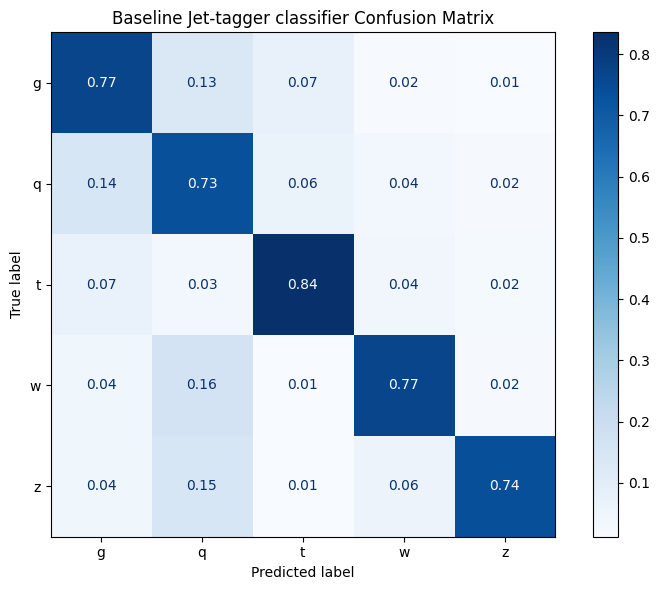

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_model = model2plot.predict(X_test)
y_test_pred = np.argmax(y_model, axis=1)
y_true = np.argmax(y_test, axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

cm_hgq = confusion_matrix(y_true, y_test_pred, normalize='true')

disp_hgq = ConfusionMatrixDisplay(confusion_matrix=cm_hgq, display_labels=classes)
disp_hgq.plot(ax=ax, cmap=plt.cm.Blues, values_format='.2f')

ax.set_title('Baseline Jet-tagger classifier Confusion Matrix')

plt.tight_layout()
plt.show()